# Hyperscaler Capital Expenditure and GPU/Memory Demand: An Exploratory Analysis

**Question:** As hyperscaler AI infrastructure capex ramps, how closely — and with what lag — does that show up in memory supplier revenue, margins, and HBM demand?

In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'seaborn'], returncode=0)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("Hyperscaler Financials Data - Cleaned Data.csv")
df.head(10)

hyperscaler_raw = pd.read_csv("Hyperscaler Financials Data - Cleaned Data.csv")
hyperscaler_raw = hyperscaler_raw.dropna(how="all")

#quarter as a sortable period for correct chronological ordering in plots
hyperscaler_raw["quarter_dt"] = pd.PeriodIndex(
    hyperscaler_raw["quarter"].str.replace(r"Q(\d) (\d+)", r"\2-Q\1", regex=True),
    freq="Q"
)
hyperscaler_raw = hyperscaler_raw.sort_values(["company", "quarter_dt"])
hyperscaler_raw.head(5)

,company,quarter,ocf_bn,capex_bn,buybacks_bn,quarter_dt
1,Amazon,Q1 2024,18.99,14.93,0.0,2024Q1
6,Amazon,Q2 2024,25.28,17.62,0.0,2024Q2
11,Amazon,Q3 2024,25.97,22.62,0.0,2024Q3
16,Amazon,Q4 2024,45.64,27.83,0.0,2024Q4
21,Amazon,Q1 2025,17.02,25.02,0.0,2025Q1


   quarter quarter_dt  capex_usd (billion)
0  Q1 2024     2024Q1                47.09
3  Q2 2024     2024Q2                55.15
5  Q3 2024     2024Q3                62.83
7  Q4 2024     2024Q4                78.20
1  Q1 2025     2025Q1                80.99
4  Q2 2025     2025Q2                96.75
6  Q3 2025     2025Q3               109.30
8  Q4 2025     2025Q4               137.27
2  Q1 2026     2026Q1               146.24


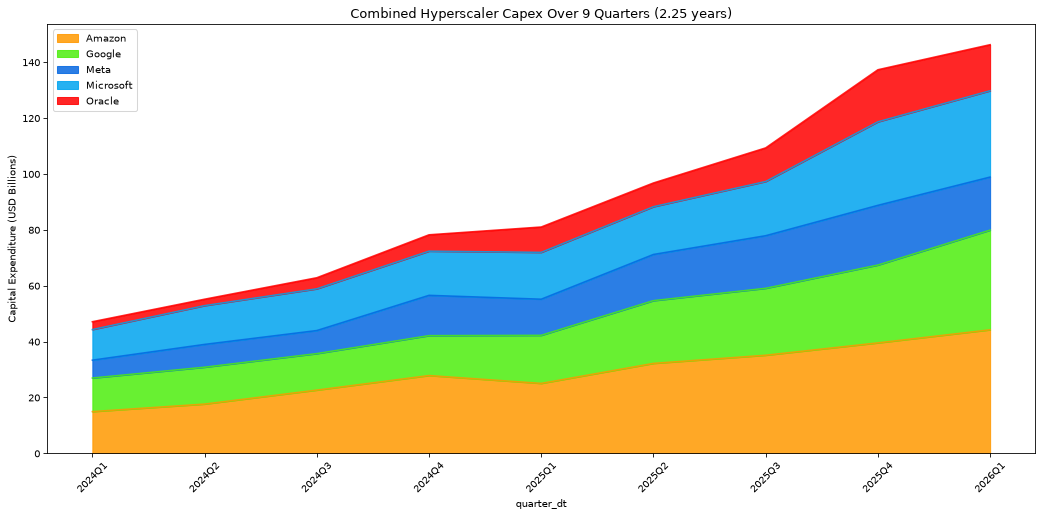

In [3]:
plt.rcParams["figure.dpi"] = 75

colors = {
    "Microsoft": "#00A4EF",
    "Amazon": "#FF9900",
    "Meta": "#0668E1",
    "Google": "#4DEE0E",
    "Oracle": "#FF0000"
}

hyperscaler_capex_total = (
    hyperscaler_raw.groupby(["quarter", "quarter_dt"])["capex_bn"].sum()
    .reset_index().sort_values("quarter_dt")
    .rename(columns={"capex_bn": "capex_usd (billion)"})
)
print(hyperscaler_capex_total.head(10))

pivot = hyperscaler_raw.pivot(index="quarter_dt", columns="company", values="capex_bn").sort_index()
pivot.index = pivot.index.astype(str)
fig, ax = plt.subplots(figsize=(14, 7))
pivot.plot.area(ax=ax, color=[colors.get(c, "gray") for c in pivot.columns], alpha=0.85)
ax.set_ylabel("Capital Expenditure (USD Billions)")
ax.set_title("Combined Hyperscaler Capex Over 9 Quarters (2.25 years)")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Amazon: 72.1%
Google: 72.3%
Meta: 72.3%
Microsoft: 67.9%
Oracle: 142.7%

Combined Hyperscaler Capex CAGR: 76.2%


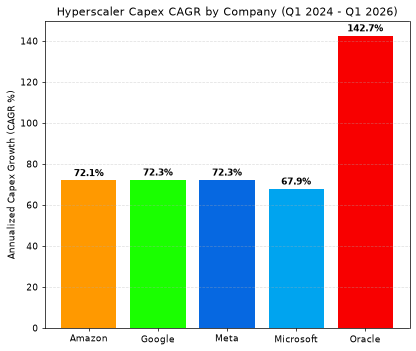

In [4]:
plt.rcParams["figure.dpi"] = 65

colors = {
    "Microsoft": "#00A4EF",
    "Amazon": "#FF9900",
    "Meta": "#0668E1",
    "Google": "#1AFF00",
    "Oracle": "#F80000"
}

#CAGR per company
cagr_by_company = {}
for company in hyperscaler_raw["company"].unique():
    company_data = hyperscaler_raw[hyperscaler_raw["company"] == company].sort_values("quarter_dt")
    capex_values = company_data["capex_bn"].tolist()
    start = capex_values[0]
    end = capex_values[-1]
    num_quarters = len(capex_values) - 1
    cagr = (end / start) ** (4 / num_quarters) - 1
    cagr_by_company[company] = cagr
for company, cagr in cagr_by_company.items():
    print(f"{company}: {cagr:.1%}")

#CAGR for combined total capex
total_by_quarter = hyperscaler_raw.groupby("quarter_dt")["capex_bn"].sum().sort_index()
total_values = total_by_quarter.tolist()
start = total_values[0]
end = total_values[-1]
num_quarters = len(total_values) - 1
total_cagr = (end / start) ** (4 / num_quarters) - 1
print(f"\nCombined Hyperscaler Capex CAGR: {total_cagr:.1%}")

#Bar chart of CAGR by company
companies = list(cagr_by_company.keys())
cagr_values = [cagr_by_company[c] * 100 for c in companies]  # convert to percentage
fig, ax = plt.subplots(figsize=(6.5, 5.5))
bars = ax.bar(companies, cagr_values, color=[colors.get(c, "gray") for c in companies])
for bar, value in zip(bars, cagr_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Annualized Capex Growth (CAGR %)")
ax.set_title("Hyperscaler Capex CAGR by Company (Q1 2024 - Q1 2026)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

company      Amazon     Google       Meta  Microsoft      Oracle
quarter                                                         
Q1 2024   78.620326  41.629116  33.246753  34.304511   46.052632
Q2 2024   69.699367  49.512012  42.178627  37.284946   30.955585
Q3 2024   87.100501  42.540717  33.414239  43.651258  305.384615
Q4 2024   60.977213  36.512401  51.554126  70.883804   98.819562
Q1 2025  147.003525  47.579530  53.849355  45.221382  147.402597
Q2 2025   98.954490  80.900901  64.710485  40.046893  104.422604
Q3 2025   98.789755  49.473249  62.766667  43.031514  581.159420
Q4 2025   72.567022  53.148855  59.044463  83.557047  260.699301
Q1 2026  169.804072  77.899105  58.951288  66.152528  112.790698


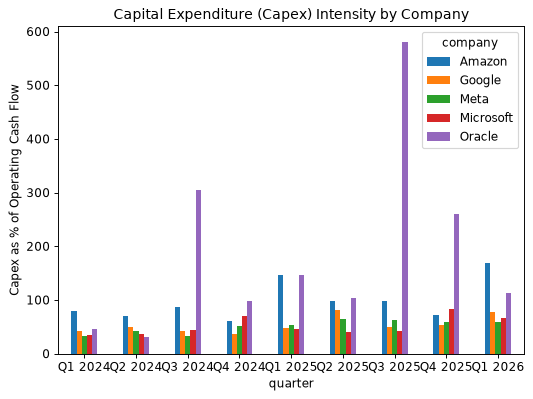

In [5]:
plt.rcParams["figure.dpi"] = 85

hyperscaler_raw["capex_pct_ocf"] = hyperscaler_raw["capex_bn"] / hyperscaler_raw["ocf_bn"] * 100
hyperscaler_raw["buyback_pct_ocf"] = hyperscaler_raw["buybacks_bn"] / hyperscaler_raw["ocf_bn"] * 100
pivot = hyperscaler_raw.pivot(index="quarter", columns="company", values="capex_pct_ocf")

#reorder chronologically to ensure correct order in the bar chart
quarter_order = hyperscaler_raw.sort_values("quarter_dt")["quarter"].unique()
pivot = pivot.reindex(quarter_order)
print(pivot)

#plotting the bar charts
fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Capex as % of Operating Cash Flow")
ax.set_title("Capital Expenditure (Capex) Intensity by Company")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

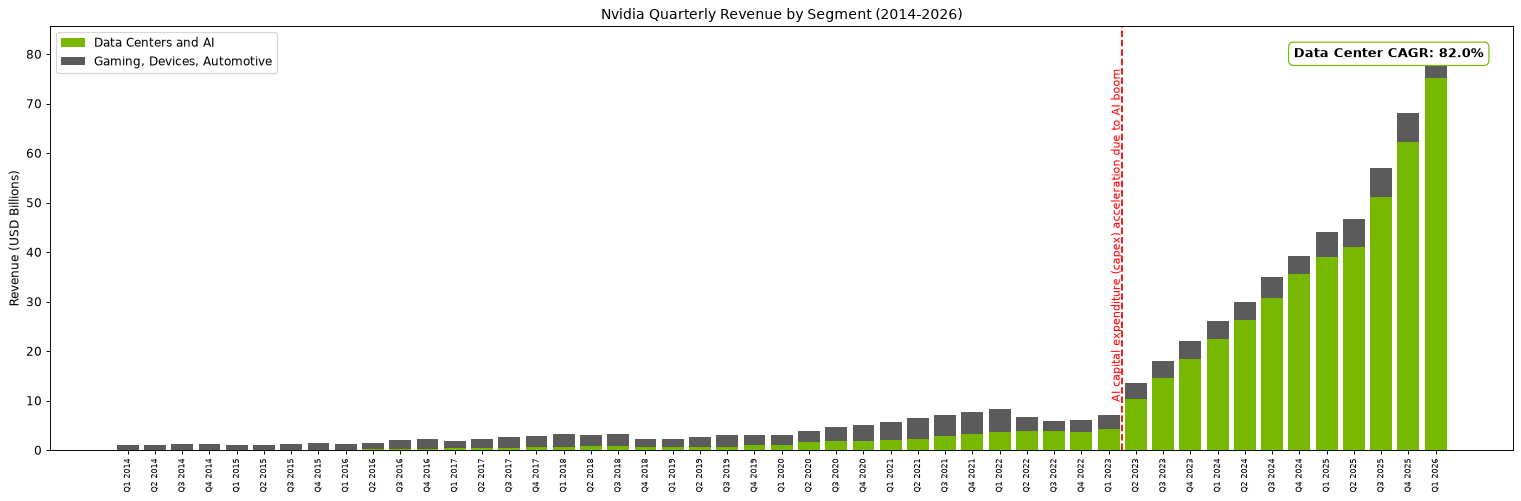

In [6]:
#Load the data
df = pd.read_csv("nvidia_quarterly_revenue_segment_cleaned.csv")

#Pull out just the two segments we need
data_center = df[df["Revenue"] == "Data centers and AI"].reset_index(drop=True)
gaming = df[df["Revenue"] == "Gaming, devices, automotive"].reset_index(drop=True)
quarters = data_center["Quarter"].tolist()
dc_revenue = pd.to_numeric(data_center["NVIDIA's quarterly revenue (billion)"]).tolist()
gaming_revenue = pd.to_numeric(gaming["NVIDIA's quarterly revenue (billion)"]).tolist()

#Calculate CAGR (annualized growth rate)
start = dc_revenue[0]
end = dc_revenue[-1]
num_quarters = len(dc_revenue) - 1
cagr = (end / start) ** (4 / num_quarters) - 1

#Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(quarters, dc_revenue, label="Data Centers and AI", color="#76b900")
ax.bar(quarters, gaming_revenue, bottom=dc_revenue, label="Gaming, Devices, Automotive", color="#5b5b5b")
ax.set_ylabel("Revenue (USD Billions)")
ax.set_title("Nvidia Quarterly Revenue by Segment (2014-2026)")
ax.legend(loc="upper left")
ax.text(0.98, 0.95, f"Data Center CAGR: {cagr:.1%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#76b900"))

#Mark AI capex acceleration point
split_index = quarters.index("Q1 2023")
ax.axvline(x=split_index+0.5, color="red", linestyle="--", linewidth=1.5, alpha=1)
ax.text(split_index + 0.5, ax.get_ylim()[1] * 0.9, "AI capital expenditure (capex) acceleration due to AI boom",
        rotation=90, color="red", fontsize=9, ha="right", va="top")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

  Market Share  Q1 2025  Q2 2025  Q3 2025  Q4 2025  Q1 2026
0      Samsung     34.0     33.0     33.0     36.0     38.0
1     SK Hynix     36.0     39.0     33.0     32.0     29.0
2       Micron     25.0     22.0     26.0     22.0     22.0
3         CXMT      3.0      4.0      6.0      8.0      8.0
4        Nanya      1.0      1.0      2.0      2.0      2.0
5       Others      0.0      1.0      1.0      1.0      1.0


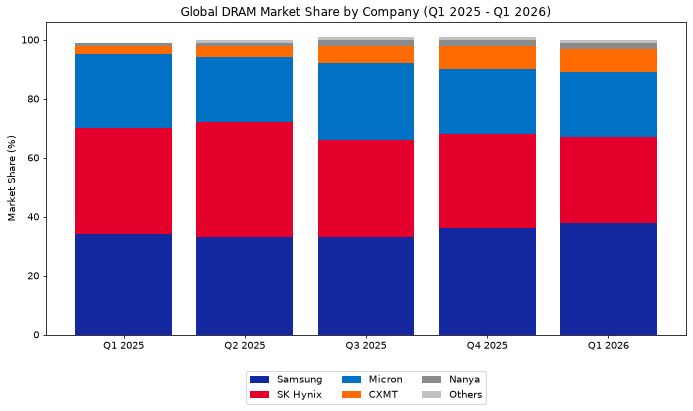

In [7]:
plt.rcParams["figure.dpi"] = 70
df = pd.read_csv("dram_market_share_counterpoint.csv")

# Strip % signs and convert to numeric
quarters = df.columns[1:]
for q in quarters:
    df[q] = df[q].str.rstrip("%").astype(float)

companies = df["Market Share"].tolist()
colors = {
    "Samsung": "#1428A0",
    "SK Hynix": "#E4002B",
    "Micron": "#0071C5",
    "CXMT": "#FF6B00",
    "Nanya": "#8B8B8B",
    "Others": "#C0C0C0"
}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = [0] * len(quarters)
for i, company in enumerate(companies):
    values = df.iloc[i][quarters].tolist()
    ax.bar(quarters, values, bottom=bottom, label=company, color=colors.get(company, "gray"))
    bottom = [b + v for b, v in zip(bottom, values)]
ax.set_ylabel("Market Share (%)")
ax.set_title("Global DRAM Market Share by Company (Q1 2025 - Q1 2026)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

print(df)
plt.tight_layout()
plt.show()

   quarter  dram_revenue_bn  nand_revenue_bn  gross_margin quarter_dt
0  Q1 2025            6.123            1.855          37.0     2025Q1
1  Q2 2025            7.071            2.155          38.0     2025Q2
2  Q3 2025            8.984            2.252          45.7     2025Q3
3  Q4 2025           10.812            2.743          56.0     2025Q4
4  Q1 2026           18.768            4.997          74.0     2026Q1
5  Q2 2026           31.328            9.943          85.0     2026Q2


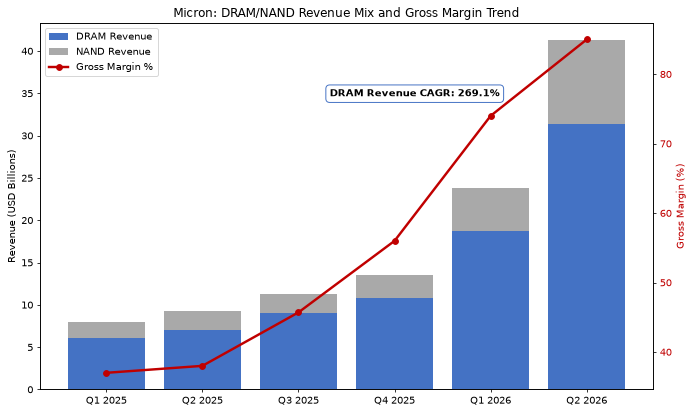

In [8]:
micron = pd.read_csv("micron_financials_cleaned.csv")
micron["gross_margin"] = micron["gross_margin"].str.rstrip("%").astype(float)
micron["quarter_dt"] = pd.PeriodIndex(
    micron["quarter"].str.replace(r"Q(\d) (\d+)", r"\2-Q\1", regex=True),
    freq="Q"
)
micron = micron.sort_values("quarter_dt")
print(micron)

fig, ax1 = plt.subplots(figsize=(10, 6))

#stacked bar chart for DRAM and NAND revenue
ax1.bar(micron["quarter"], micron["dram_revenue_bn"], label="DRAM Revenue", color="#4472C4")
ax1.bar(micron["quarter"], micron["nand_revenue_bn"], bottom=micron["dram_revenue_bn"],
         label="NAND Revenue", color="#A9A9A9")
ax1.set_ylabel("Revenue (USD Billions)")
ax1.set_title("Micron: DRAM/NAND Revenue Mix and Gross Margin Trend")

#line chart for gross margin on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(micron["quarter"], micron["gross_margin"], color="#C00000",
         marker="o", linewidth=2.5, label="Gross Margin %")
ax2.set_ylabel("Gross Margin (%)", color="#C00000")
ax2.tick_params(axis="y", labelcolor="#C00000")

#combine both legends into one box
bars, bar_labels = ax1.get_legend_handles_labels()
lines, line_labels = ax2.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + line_labels, loc="upper left")

#DRAM revenue CAGR annotation
dram_start = micron["dram_revenue_bn"].iloc[0]
dram_end = micron["dram_revenue_bn"].iloc[-1]
num_quarters = len(micron) - 1
dram_cagr = (dram_end / dram_start) ** (4 / num_quarters) - 1
ax1.text(0.75, 0.82, f"DRAM Revenue CAGR: {dram_cagr:.1%}",
          transform=ax1.transAxes, ha="right", va="top",
          fontsize=10, fontweight="bold",
          bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#4472C4"))

plt.tight_layout()
plt.show()

In [9]:
#%pip install pandas matplotlib seaborn scipy
from scipy.stats import pearsonr

#aggregate hyperscaler capex to a single total per quarter
capex_total = hyperscaler_raw.groupby(["quarter", "quarter_dt"])["capex_bn"].sum().reset_index()

#merge with Micron DRAM revenue on quarter
merged = capex_total.merge(micron[["quarter", "quarter_dt", "dram_revenue_bn"]], 
                             on=["quarter", "quarter_dt"], how="inner")
merged = merged.sort_values("quarter_dt").reset_index(drop=True)
print(merged)
print()  # blank line for output spacing

#conduct lag analysis to see if hyperscaler capex is correlated with Micron DRAM revenue with a lag of 0, 1, or 2 quarters
for lag in [0, 1, 2]:
    #shift DRAM revenue backward by `lag` quarters, so capex[t] lines up with dram_revenue[t+lag]
    shifted_dram = merged["dram_revenue_bn"].shift(-lag)
    
    valid = merged["capex_bn"].notna() & shifted_dram.notna()
    
    if valid.sum() >= 3:  #need at least 3 points for a meaningful correlation
        r, p = pearsonr(merged.loc[valid, "capex_bn"], shifted_dram[valid])
        print(f"Lag {lag} quarter(s): r = {r:.3f}, p = {p:.3f}, n = {valid.sum()}")
    else:
        print(f"Lag {lag} quarter(s): not enough overlapping data points")

   quarter quarter_dt  capex_bn  dram_revenue_bn
0  Q1 2025     2025Q1     80.99            6.123
1  Q2 2025     2025Q2     96.75            7.071
2  Q3 2025     2025Q3    109.30            8.984
3  Q4 2025     2025Q4    137.27           10.812
4  Q1 2026     2026Q1    146.24           18.768

Lag 0 quarter(s): r = 0.879, p = 0.049, n = 5
Lag 1 quarter(s): r = 0.979, p = 0.021, n = 4
Lag 2 quarter(s): r = 0.916, p = 0.263, n = 3


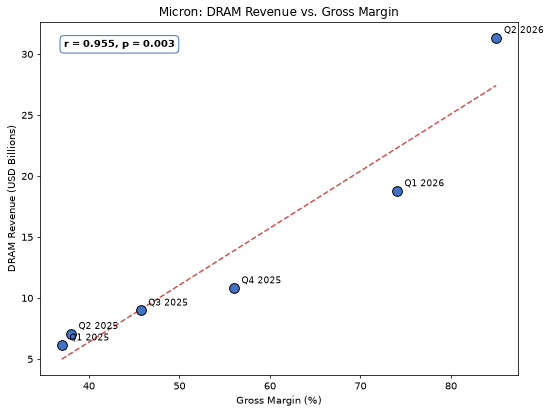

DRAM Revenue vs Gross Margin: r = 0.955, p = 0.003, n = 6


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(micron["gross_margin"], micron["dram_revenue_bn"], 
           s=100, color="#4472C4", edgecolor="black", zorder=3)

# Label each point with its quarter
for i, row in micron.iterrows():
    ax.annotate(row["quarter"], 
                (row["gross_margin"], row["dram_revenue_bn"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# Add trendline
import numpy as np
z = np.polyfit(micron["gross_margin"], micron["dram_revenue_bn"], 1)
trendline = np.poly1d(z)
x_range = np.linspace(micron["gross_margin"].min(), micron["gross_margin"].max(), 100)
ax.plot(x_range, trendline(x_range), color="#C00000", linestyle="--", alpha=0.7, zorder=2)

ax.set_xlabel("Gross Margin (%)")
ax.set_ylabel("DRAM Revenue (USD Billions)")
ax.set_title("Micron: DRAM Revenue vs. Gross Margin")

# Annotate correlation
r, p = pearsonr(micron["dram_revenue_bn"], micron["gross_margin"])
ax.text(0.05, 0.95, f"r = {r:.3f}, p = {p:.3f}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#4472C4"))

plt.tight_layout()
plt.show()
r, p = pearsonr(micron["dram_revenue_bn"], micron["gross_margin"])
print(f"DRAM Revenue vs Gross Margin: r = {r:.3f}, p = {p:.3f}, n = {len(micron)}")

Additionally, Micron's DRAM revenue and gross margin show a strong positive correlation (r=0.955, p=0.003) over this period, suggesting Micron's revenue growth has been driven substantially by pricing power rather than the volume of DRAM memory being sold alone due to a supply constrained and high demand market environment.

   quarter quarter_dt  capex_bn  NVIDIA's quarterly revenue (billion)  \
0  Q1 2025     2025Q1     80.99                                39.112   
1  Q2 2025     2025Q2     96.75                                41.096   
2  Q3 2025     2025Q3    109.30                                51.215   
3  Q4 2025     2025Q4    137.27                                62.314   
4  Q1 2026     2026Q1    146.24                                75.246   

   dram_revenue_bn  
0            6.123  
1            7.071  
2            8.984  
3           10.812  
4           18.768  


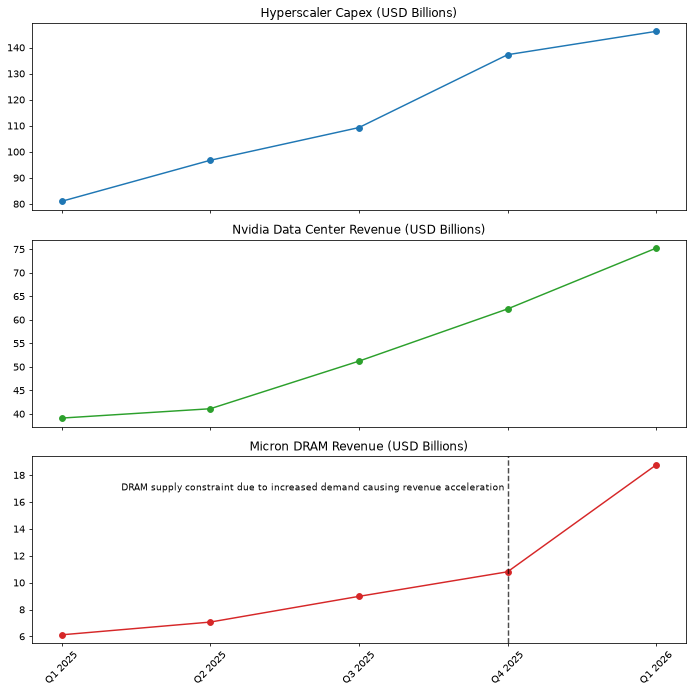

In [11]:
plt.rcParams["figure.dpi"] = 70
#merge all three datasets on quarter, keeping only quarters present in all three
combined = capex_total.merge(
    data_center[["Quarter", "NVIDIA's quarterly revenue (billion)"]].rename(columns={"Quarter": "quarter"}),
    on="quarter", how="inner"
).merge(
    micron[["quarter", "dram_revenue_bn"]],
    on="quarter", how="inner"
)

#numeric conversion for NVIDIA's quarterly revenue
combined["NVIDIA's quarterly revenue (billion)"] = pd.to_numeric(combined["NVIDIA's quarterly revenue (billion)"])
combined = combined.sort_values("quarter_dt").reset_index(drop=True)
print(combined)

#plotting the three time series in a single figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 10))

#hyperscaler capex
axes[0].plot(combined["quarter"], combined["capex_bn"], marker="o", color="tab:blue")
axes[0].set_title("Hyperscaler Capex (USD Billions)")

#Nvidia Data Center Revenue
axes[1].plot(combined["quarter"], combined["NVIDIA's quarterly revenue (billion)"], marker="o", color="tab:green")
axes[1].set_title("Nvidia Data Center Revenue (USD Billions)")

#Micron DRAM Revenue
axes[2].plot(combined["quarter"], combined["dram_revenue_bn"], marker="o", color="tab:red")
axes[2].set_title("Micron DRAM Revenue (USD Billions)")

#DRAM demand acceleration due to AI boom
quarters_list = combined["quarter"].tolist()
split_index = quarters_list.index("Q4 2025")
axes[2].axvline(x=split_index, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
axes[2].text(split_index - 0.02, axes[2].get_ylim()[1] * 0.9, "DRAM supply constraint due to increased demand causing revenue acceleration",
             rotation=0, color="black", fontsize=9, ha="right", va="top")

plt.xticks(rotation=45)
fig.tight_layout()
plt.show()